to do:
- move over functions to maui_codebook shared
- adjust data flows for fictrac to properly scale and synchronize to imaging data

In [313]:
import glob
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from maui_codebook.io import Datum_Flow
import xarray as xr
import scipy.cluster.hierarchy as shc


In [314]:

fl= Datum_Flow(
    datum_id= 'pIP10_TSeries_20260430_GC8m_fly11_win01_trial-002',
    raw_src_dir=Path('/Volumes/AhmedLab/princess/data/pIP10/raw'),
    proc_dest_dir= Path('/Volumes/AhmedLab/princess/data/pIP10/processed'),
    local_cache=Path('/Users/princesst/Documents/pIP10_results')
)

fl.merge_moco_frames()
moco_brain = np.load(fl.moco_npy, mmap_mode='r', allow_pickle=False)
moco_xarr = fl.get_moco_xarray()

brain_array = moco_brain.T
speed = fl.get_fictrack()

2779 motion corrected volumes found
deprecated, do not use nifty files as intermediate stages
Generatign single MoCo file ...
Cache found, skipping. Load running method`get_moco_xarray()`
loading moco array from disk
Loading local cache at /Users/princesst/Documents/pIP10_results/pIP10_TSeries_20260430_GC8m_fly11_win01_trial-002/moco.npy
formating MoCo data into 
parsing volume and frame timestamps from /Volumes/AhmedLab/princess/data/pIP10/raw/pIP10_TSeries_20260430_GC8m_fly11_win01_trial-002/pIP10_TSeries_20260430_GC8m_fly11_win01_trial-002.xml
loading cached ttl epochs from /Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260430_GC8m_fly11_win01_trial-002/ttl_epochs.csv
aligning xml command timestamps to ttl ground truth
truncating timestamps to video lenght


In [315]:
NCLUSTERS = 20
shape = brain_array.shape
T = brain_array.shape[-1]
win = '1'
fly = '11'

BASE_DIRECTORY = '/Volumes/AhmedLab/princess/data/pIP10/'
PROCESSED_DIR = f'{BASE_DIRECTORY}/processed/pIP10_TSeries_*_GC8m_fly{fly}_win0{win}_trial*-002/'
file = glob.glob(f'/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_*_GC8m_fly{fly}_win0{win}_trial*-001/20_supervoxels.h5')[0]


In [316]:
cluster_labels, _ = fl.get_clusters()

its signals, princess


In [317]:
import matplotlib.colors as colors
def plot_spatial_location(clusters_toplot, cluster_2d_arr, brain_dimensions):
    fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(40, 40), constrained_layout=True)
    palette_colors = sns.color_palette("twilight", 25)
    cmap = ListedColormap(palette_colors)

    axes = axes.flatten()
    blank_brain = create_blank_brain(cluster_2d_arr)
    for cluster in clusters_toplot:
        identify_single_cluster(cluster_2d_arr, blank_brain, cluster)

    blank_brain_clusters = blank_brain.reshape(brain_dimensions[2], brain_dimensions[0], brain_dimensions[1])
    raw_brain_clusters = cluster_2d_arr.reshape(brain_dimensions[2], brain_dimensions[0], brain_dimensions[1])

    for idx in range(brain_dimensions[2]):
        ax = axes[idx]
        # ax.imshow(raw_brain_clusters[idx].T, cmap="gray_r", alpha=0.7)
        ax.imshow(blank_brain_clusters[idx].T, cmap=cmap, alpha=1)
        ax.set_title(f"Slice {idx}")

    for j in range(brain_dimensions[2], len(axes)):
        fig.delaxes(axes[j])
from maui_codebook.visualizations import *

In [318]:
cluster_labels_array = cluster_labels.to_numpy()
shifted_labels_3d = np.roll(cluster_labels, shift=(-50,50), axis=(1,2))
# plot_spatial_location([[None,None]], cluster_labels_array,shape[:-1])
# plot_spatial_location([[None,None]], shifted_labels_3d,shape[:-1])

In [319]:
shifted_labels_3d.shape
z = cluster_labels.shape[0]

shifted_labels_xr = xr.DataArray(
    data=shifted_labels_3d,
    dims=['Z', 'X', 'Y'],
    coords={'Z': np.arange(z)}
)

In [320]:
from maui_codebook.supervoxels import calc_cluster_means

SuperVoxels, selected_supervoxels = calc_cluster_means(
        brain_xarray= moco_xarr,
        label_xarray= cluster_labels,
        selected_supervoxels= 'all',
        out  = None,
        showpbar=False
)

shift_SuperVoxels, shift_selected_supervoxels = calc_cluster_means(
        brain_xarray= moco_xarr,
        label_xarray= shifted_labels_xr,
        selected_supervoxels= 'all',
        out  = None,
        showpbar=False
)


In [321]:
scope_timestamps, camera_timestamps = fl.get_timestamps()
volume_timestamps = scope_timestamps.query("frame == 0").timestamp.values

In [322]:
supervoxels = np.reshape(SuperVoxels.T, shape=[shape[2], NCLUSTERS, -1])
print(supervoxels.shape)
shift_supervoxels = np.reshape(shift_SuperVoxels.T, shape=[shape[2], NCLUSTERS, -1])

(11, 20, 2779)


In [323]:
# format into x arrays
signal_xr = xr.DataArray(
    data=supervoxels,
    dims=['zposs', 'roi', 'time'],
    coords={'time': volume_timestamps}
)
sh_signal_xr = xr.DataArray(
    data=shift_supervoxels,
    dims=['zposs', 'roi', 'time'],
    coords={'time': volume_timestamps}
)

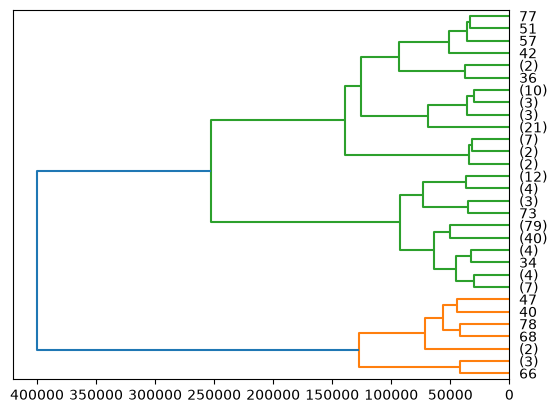

In [324]:
# CLUSTER SUPERVOXELS BY ACTIVITY OVER TIME

# cluster signal across all supervoxels by time
NCLUSTERS = 30
SLICES = shape[2]
supervox_signal = signal_xr.stack(supervoxel=['zposs', 'roi']).T
Z = shc.linkage(supervox_signal, method='ward')
_ = shc.dendrogram(Z, orientation='left', truncate_mode='lastp', p=NCLUSTERS)
clust_labels = shc.fcluster(Z, NCLUSTERS, criterion='maxclust')

# add cluster id as new coordinate
# each supervoxel now has a designated cluster id
# adds in the cluster number as a new coordinate - each supervoxel has a designated cluster
grouped_sv = supervox_signal.assign_coords(cluster = ('supervoxel', clust_labels)).set_index(supervoxel='cluster', append=True)


(11, 512, 512)


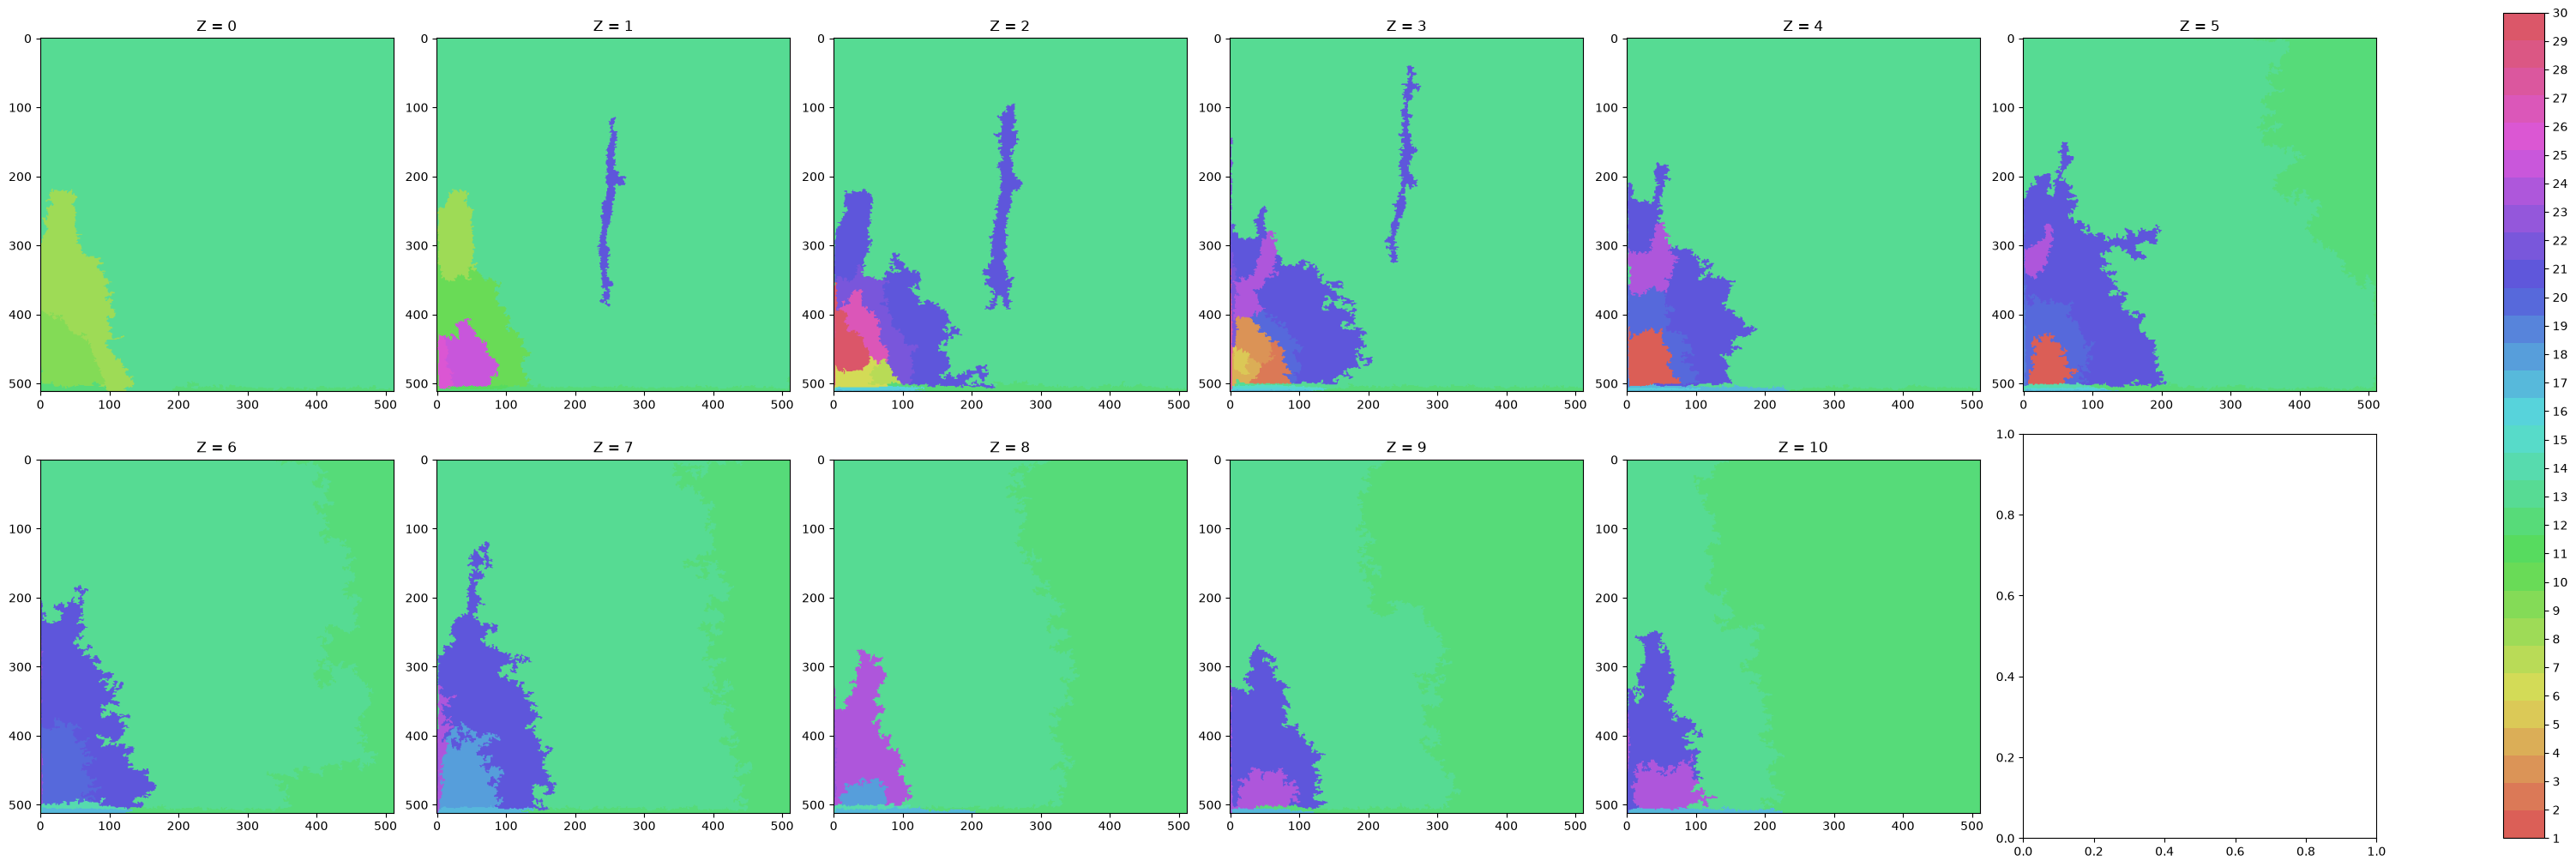

In [325]:

# color spatial maps by cluster id
clusters_spatial = np.empty(cluster_labels.shape, dtype=int)
print(clusters_spatial.shape)
for z, px_list in enumerate(cluster_labels):
    # find cluster value
    values = grouped_sv.supervoxel.sel(supervoxel=z).cluster.values

    for px, sv in enumerate(px_list):
        clusters_spatial[z, px] = values[sv]

norm = colors.Normalize(vmin=1, vmax=NCLUSTERS)
palette_colors = sns.color_palette("hls", NCLUSTERS)
cmap = ListedColormap(palette_colors)
#
fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(30, 10), constrained_layout=True)
axes = axes.flatten()

for z in range(SLICES):
    ax = axes[z]
    image = np.reshape(clusters_spatial[z], [512, 512])
    map = ax.imshow(image.T, cmap=cmap, norm=norm)
    ax.set_title(f'Z = {z}')
plt.colorbar(map, ax=axes.ravel(), ticks=np.arange(1, NCLUSTERS + 1))

In [326]:
import matplotlib.colors as colors
def plot_spatial_location(clusters_toplot, cluster_2d_arr, brain_dimensions):
    fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(40, 40), constrained_layout=True)
    palette_colors = sns.color_palette("hls", len(clusters_toplot))

    axes = axes.flatten()
    blank_brain = create_blank_brain(cluster_2d_arr)
    for cluster in clusters_toplot:
        identify_single_cluster(cluster_2d_arr, blank_brain, cluster)

    blank_brain_clusters = blank_brain.reshape(brain_dimensions[2], brain_dimensions[0], brain_dimensions[1])
    raw_brain_clusters = cluster_2d_arr.reshape(brain_dimensions[2], brain_dimensions[0], brain_dimensions[1])

    for idx in range(brain_dimensions[2]):
        ids = np.unique(blank_brain_clusters[idx].T)
        unique_vals = ids[~np.isnan(ids)]
        cmap_len = len(unique_vals)
        # color selection
        if idx == 0:
            start_color = 0
        end_color = 0
        if cmap_len > 0:
            end_color = start_color + cmap_len
        cmap = ListedColormap(palette_colors[start_color:end_color])
        # print(f'start_color = {start_color}, end_color = {end_color}')
        ax = axes[idx]

        ax.imshow(raw_brain_clusters[idx].T, cmap="gray_r", alpha=0.5)
        ax.imshow(blank_brain_clusters[idx].T, cmap=cmap, alpha=1)
        ax.set_title(f"Slice {idx}")
        start_color += cmap_len

    for j in range(brain_dimensions[2], len(axes)):
        fig.delaxes(axes[j])

9
[[1, 8], [2, 4], [2, 5], [2, 8], [2, 13], [2, 19], [3, 1], [3, 10], [3, 12]]
number of selected pIP10 rois: 4


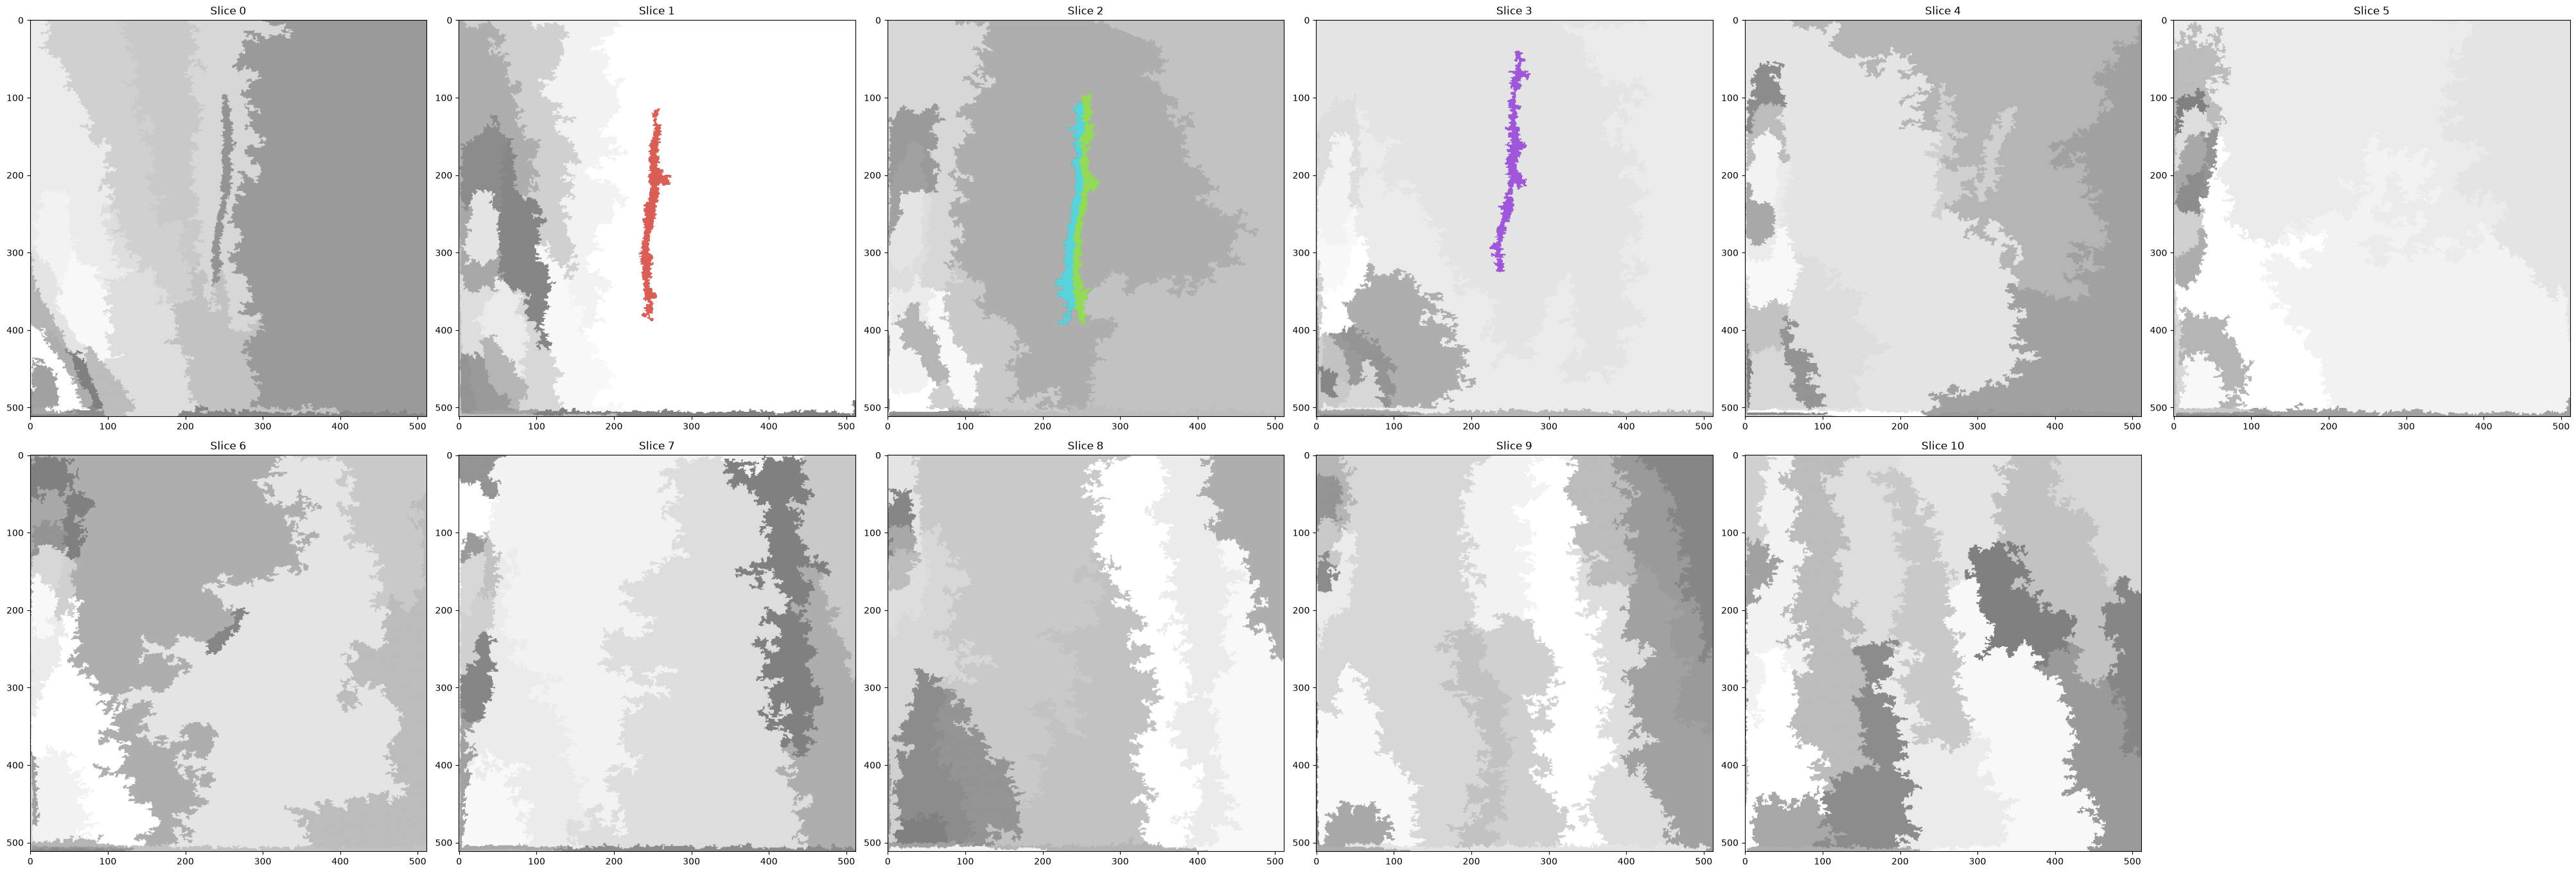

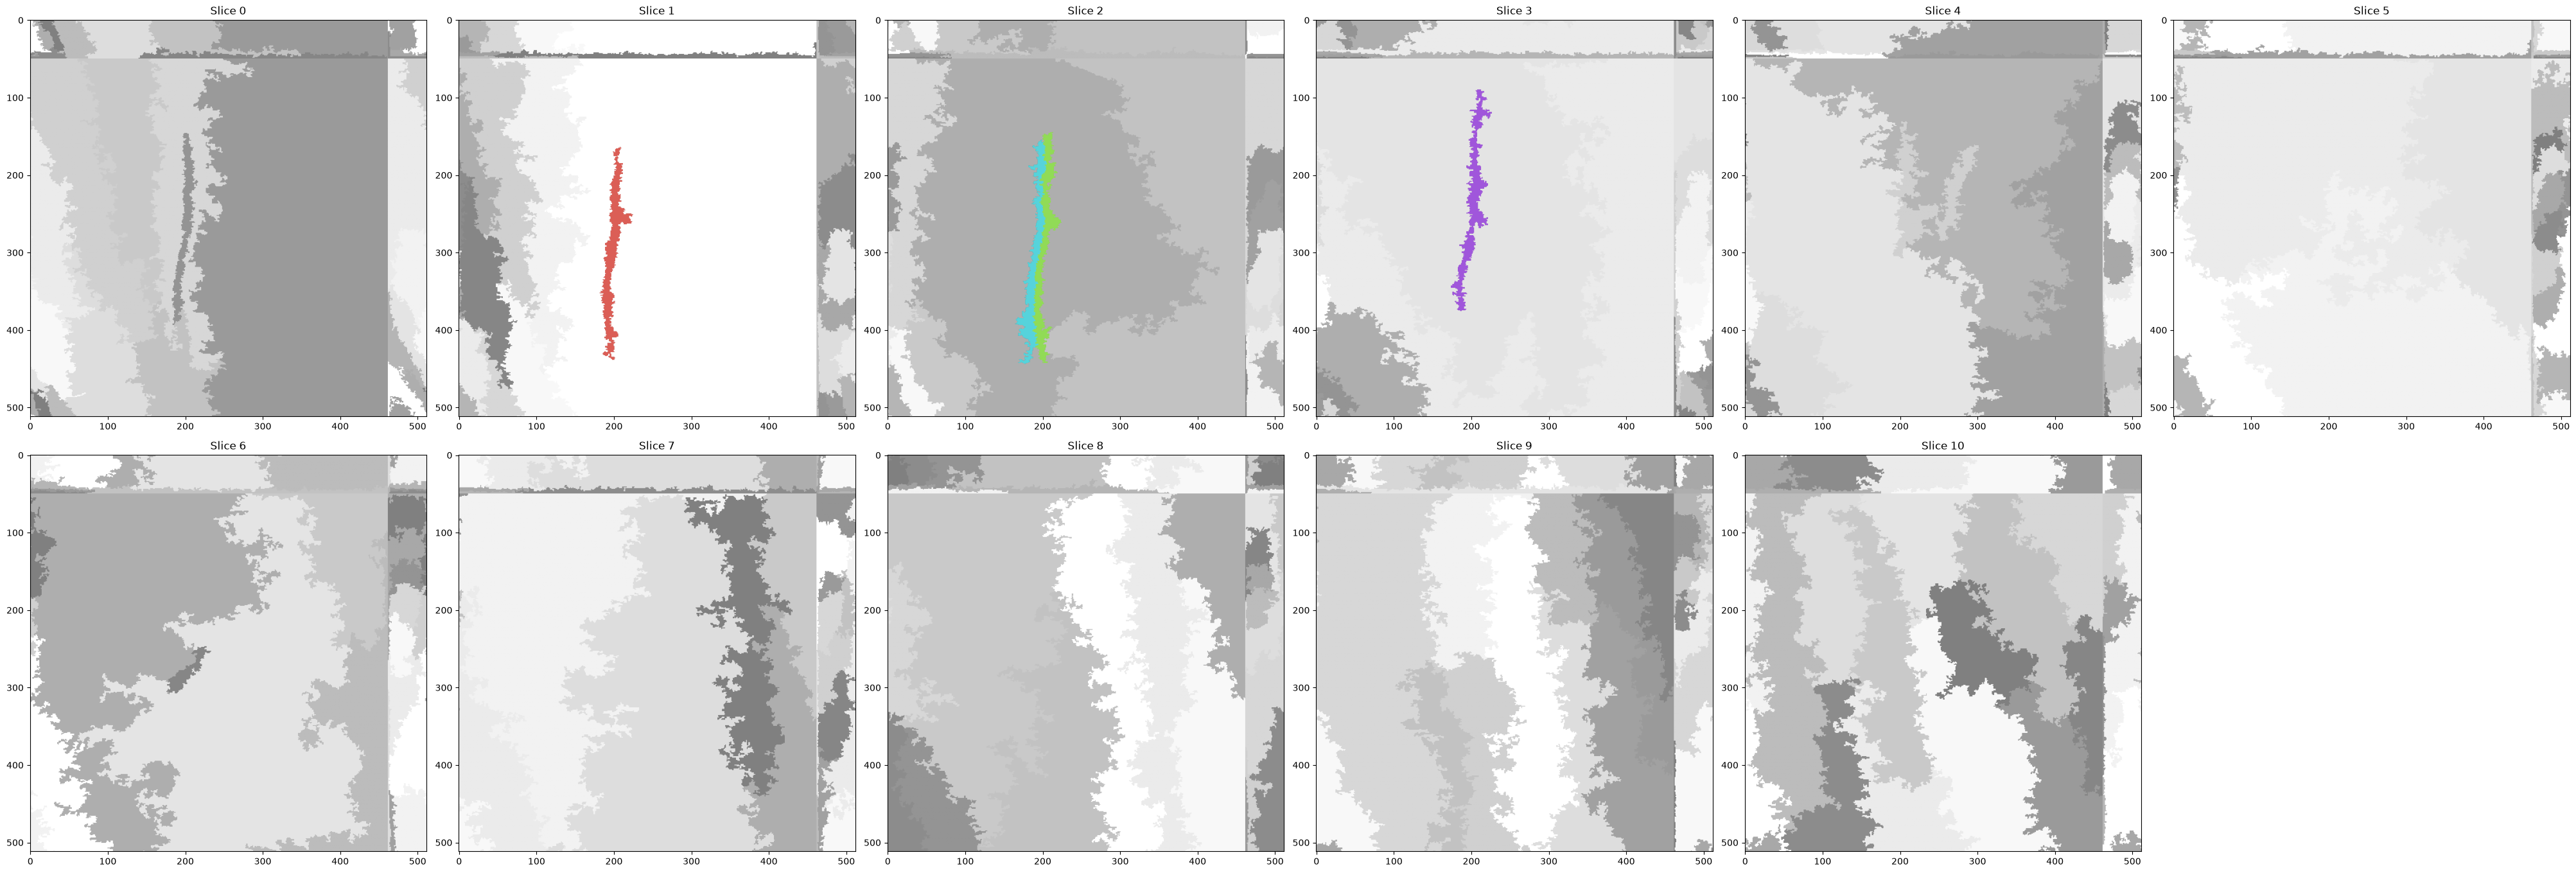

In [336]:
# select cool cluster
COOL_CLUSTER = 21

supervoxel_subset = []
DIMENSIONS = [shape[0], shape[1]]
for z in range(1,4):  # slice range
    values = grouped_sv.supervoxel.sel(zposs=z).cluster.values
    for idx, v in enumerate(values):
        if v == COOL_CLUSTER:
            supervoxel_subset.append([z, idx])
print(len(supervoxel_subset))

indexs = [0, 4,5,7]
pip_rois = [supervoxel_subset[x] for x in indexs]
print(supervoxel_subset)
print(f'number of selected pIP10 rois: {len(pip_rois)}')
spatial_2d = np.reshape(cluster_labels_array, shape=[11,-1])
sh_spatial_2d = np.reshape(shifted_labels_3d, shape=[11,-1])

plot_spatial_location(pip_rois, spatial_2d, shape[:-1])
plot_spatial_location(pip_rois, sh_spatial_2d, shape[:-1])

In [337]:
def plot_zscored_activity(clusters_toplot, signal_xarray, behavior_array, yshift = 1, title = None):
    # fig, axes = plt.subplots(ncols=1,nrows=2, figsize=(20, len(clusters_toplot)), gridspec_kw={'width_ratios': [3, 1]})
    fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(20, 15),
    gridspec_kw={'height_ratios': [4, 1]},
    sharex=True,
)
    fig.tight_layout()
    palette_colors = sns.color_palette("hls", len(clusters_toplot))
    # axes = axes.flatten()

    for idx, ind_cluster in enumerate(clusters_toplot):
        to_plot = signal_xarray.isel(zposs=ind_cluster[0], roi=ind_cluster[1])
        ax1.plot(signal_xarray.coords["time"], to_plot + (yshift * idx), color=palette_colors[idx])
        if title is not None:
            ax1.set_title(f'{title}')

    ax2.plot(behavior_array.coords['time'],behavior_array)
    ax2.set_title('walking speed')
    ax2.set_ylim(0,20)

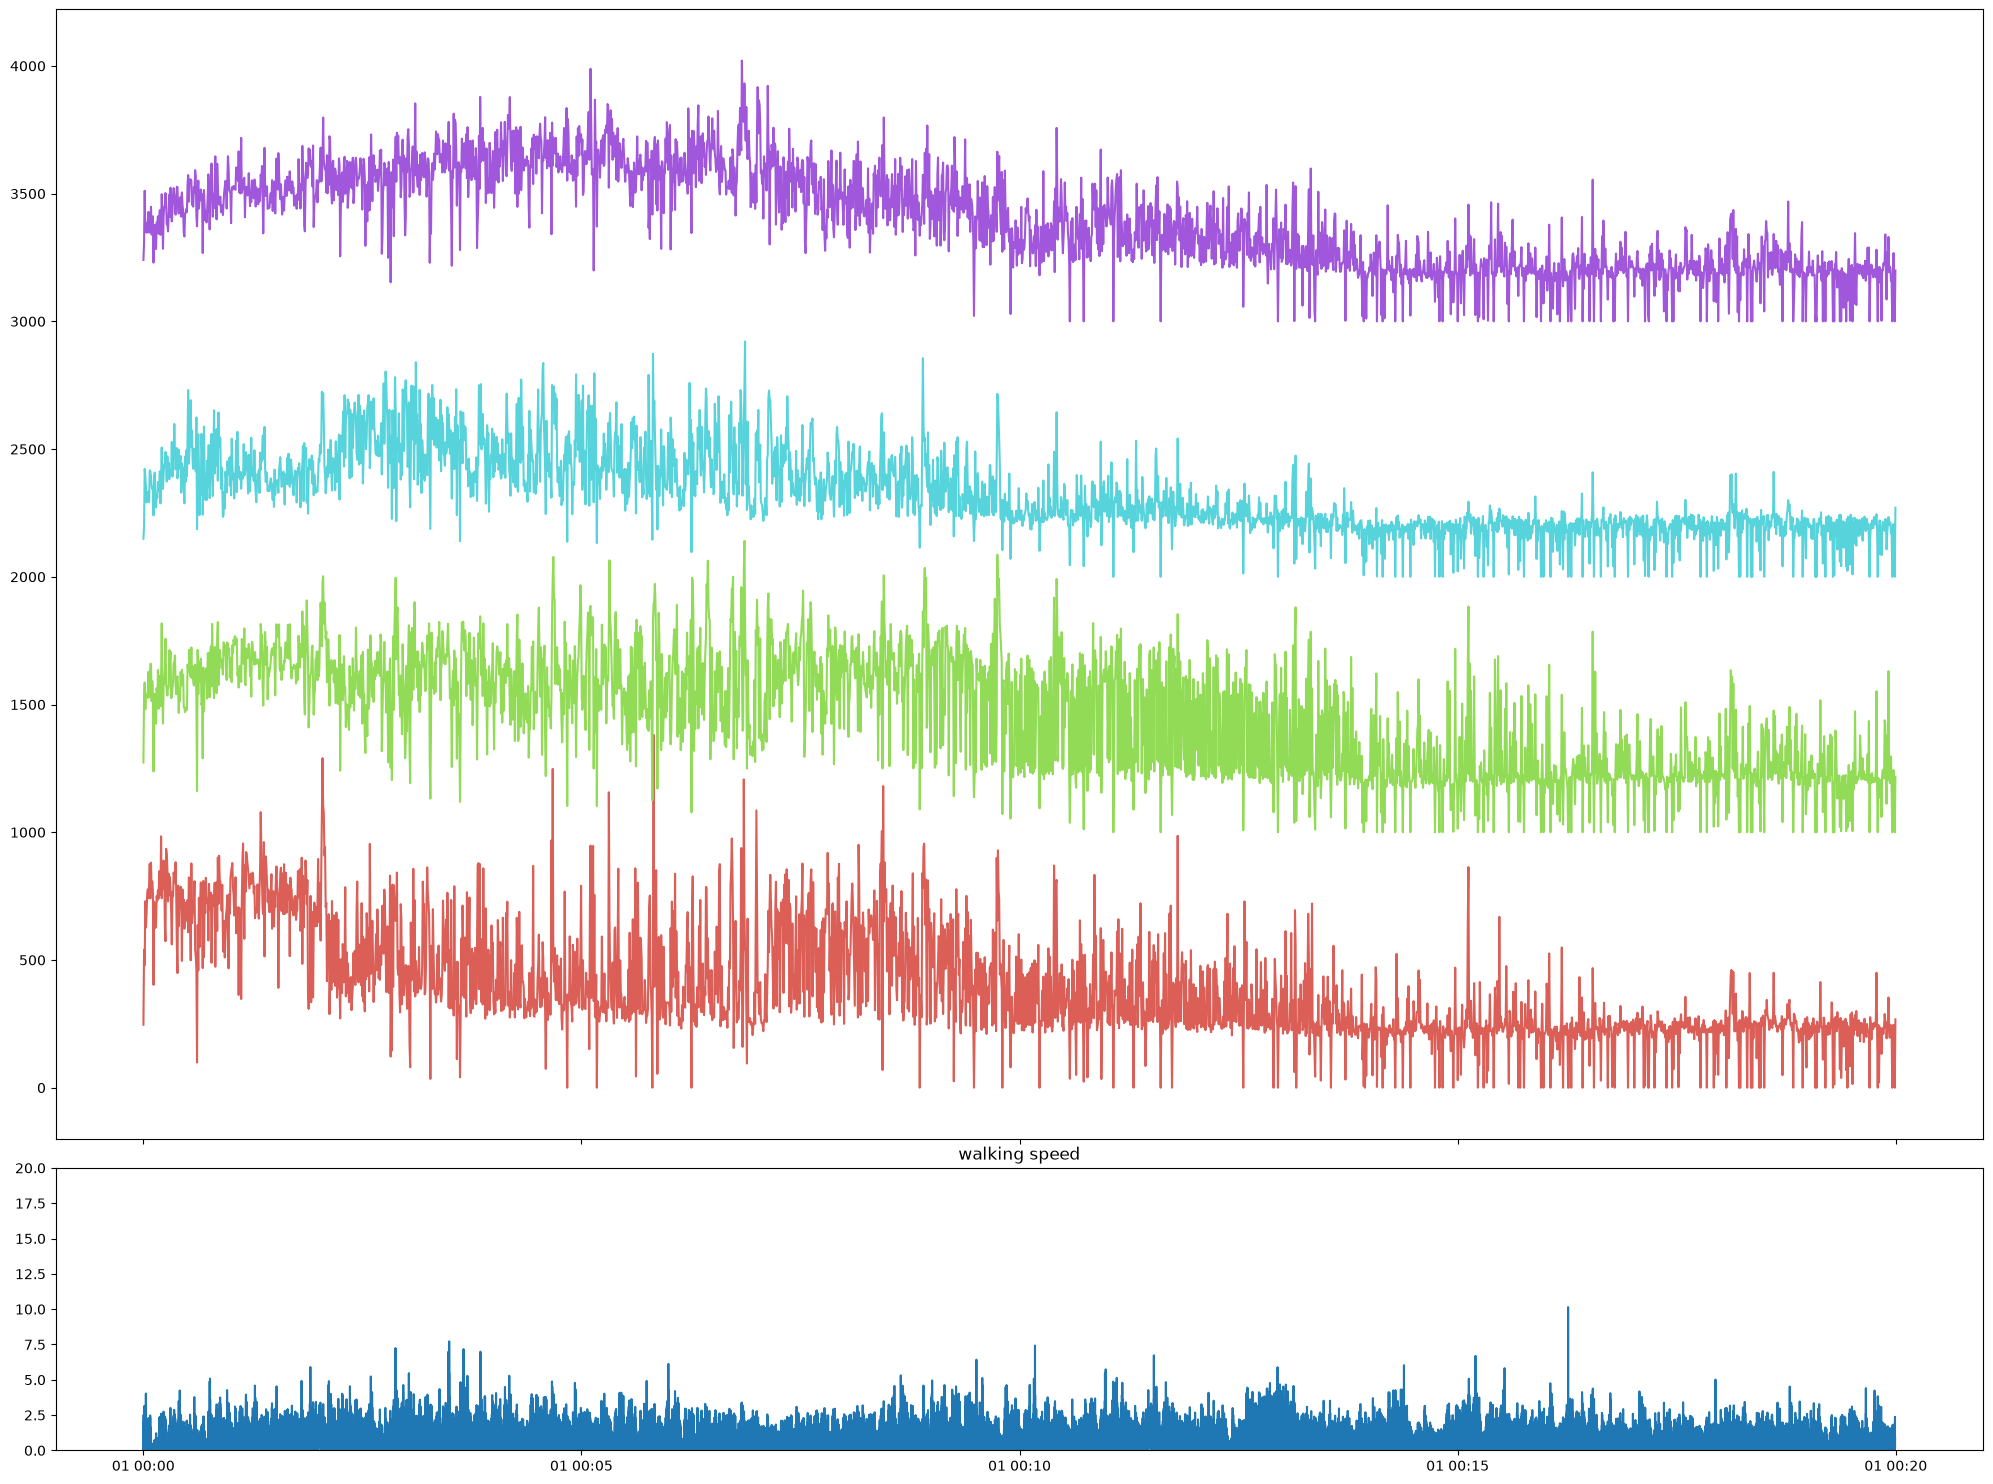

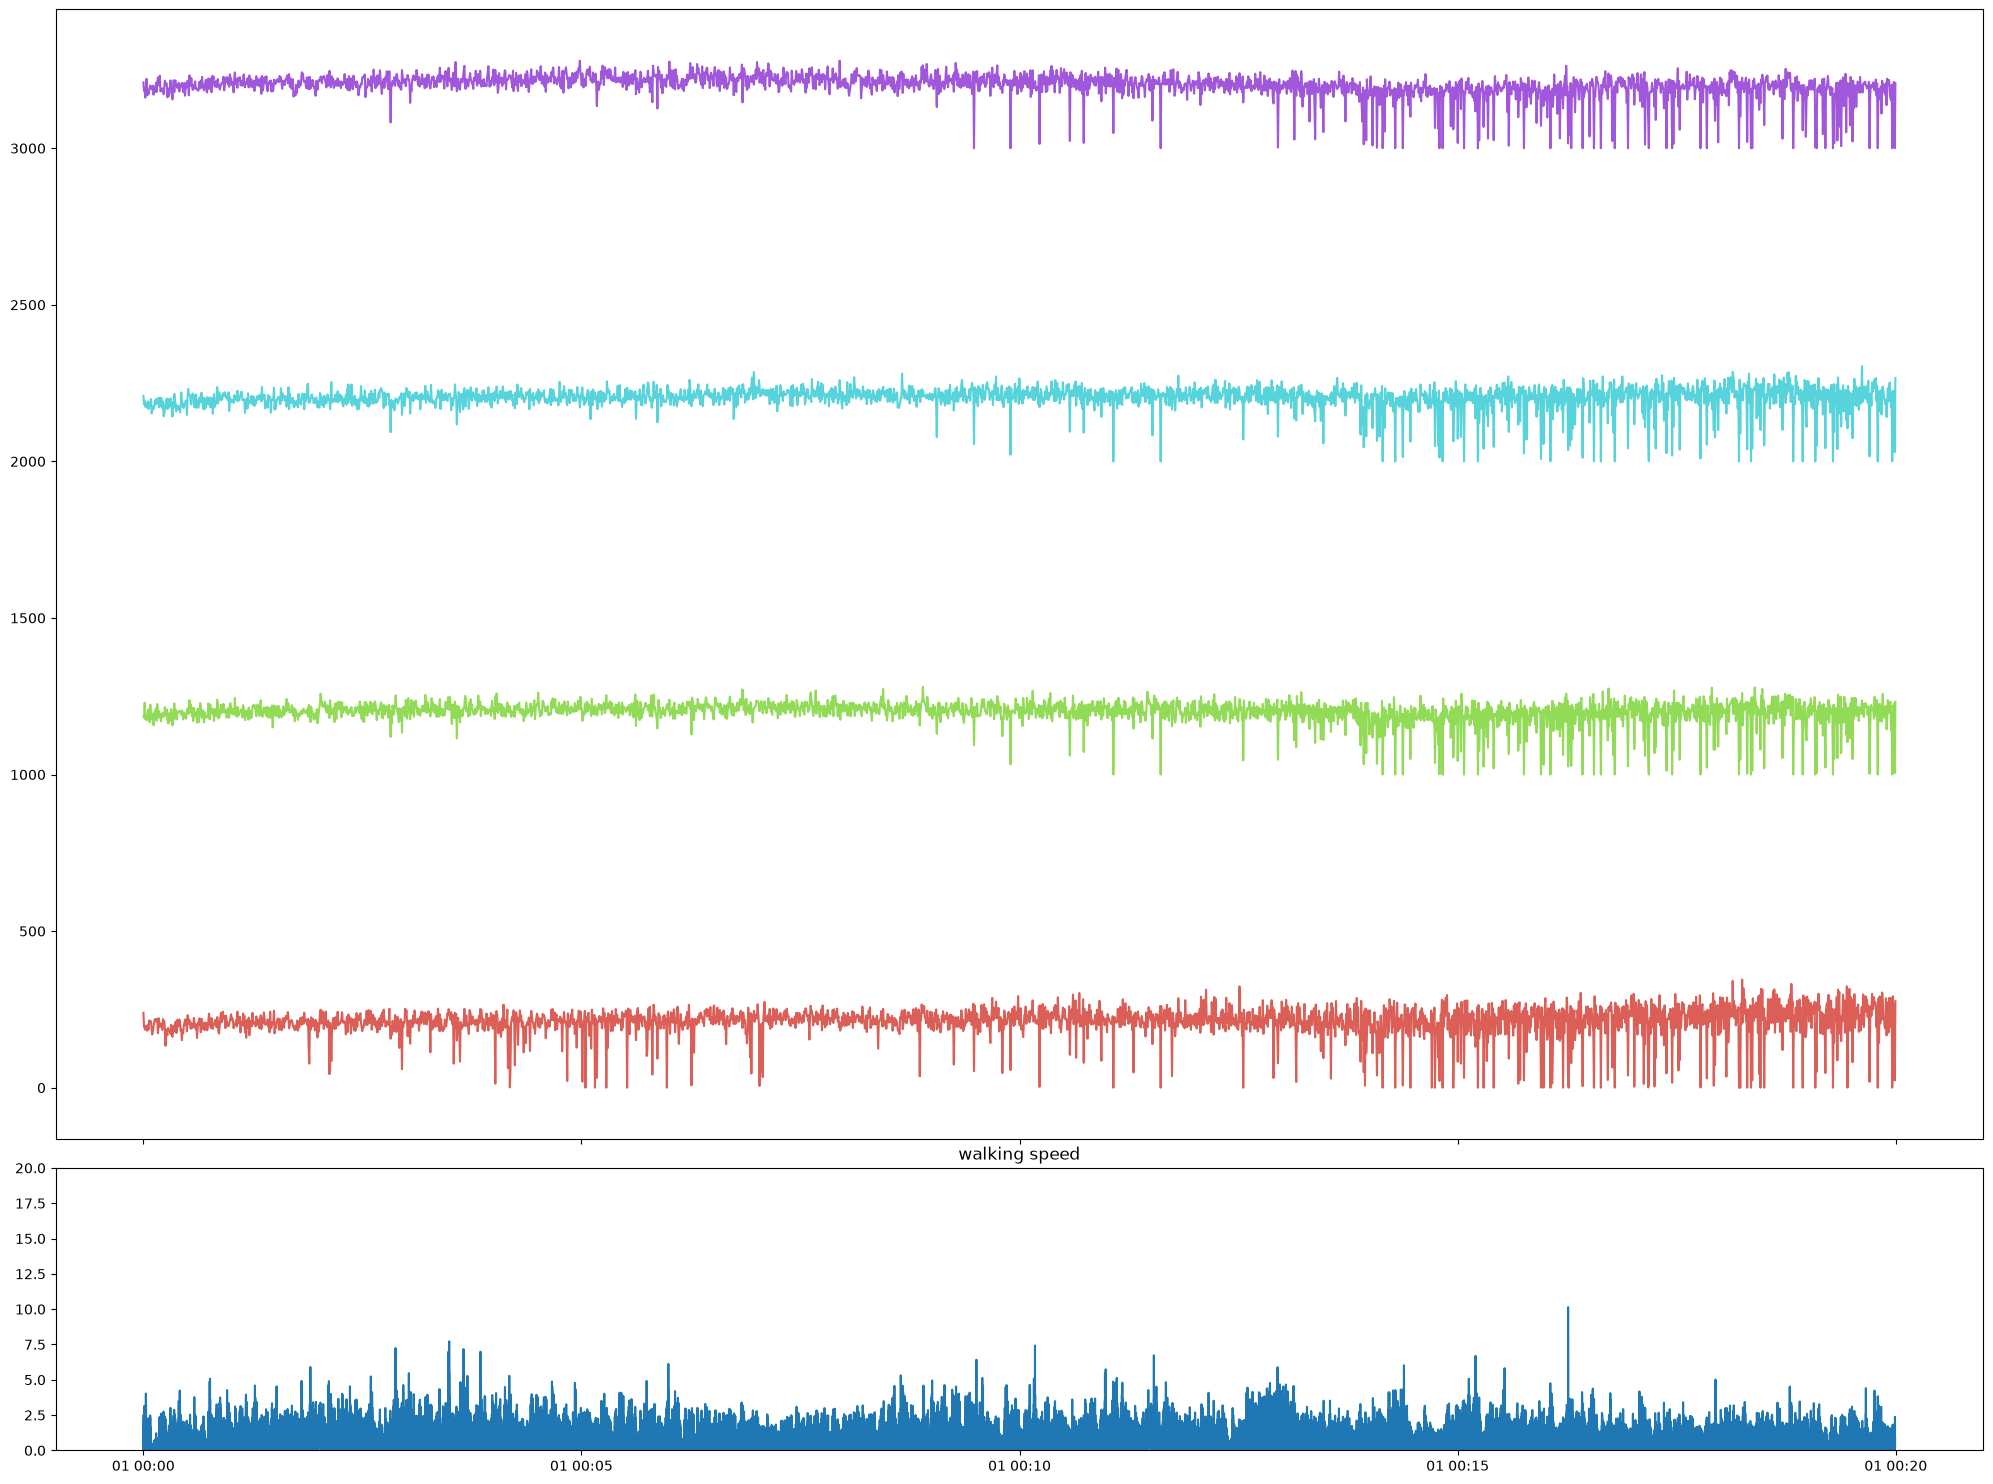

In [343]:
plot_zscored_activity(pip_rois, signal_xr, speed, yshift = 1000)
plot_zscored_activity(pip_rois, sh_signal_xr, speed, yshift = 1000)


In [339]:
interp_speed = speed.interp_like(signal_xr, kwargs={"fill_value": "extrapolate"})
speed_shared, signal_shared = xr.align(interp_speed, signal_xr, join="inner")

speed_shared, sh_signal_shared = xr.align(interp_speed, sh_signal_xr, join="inner")

DRIFT_INDEX = 1500
trunc_signal = signal_shared.isel(time=slice(0, DRIFT_INDEX))
trunc_sh_signal = sh_signal_shared.isel(time=slice(0, DRIFT_INDEX))
trunc_behavior = speed_shared.isel(time=slice(0, DRIFT_INDEX))

correlation = xr.corr(speed_shared, signal_shared, dim="time")
sh_correlation = xr.corr(sh_signal_shared, signal_shared, dim="time")


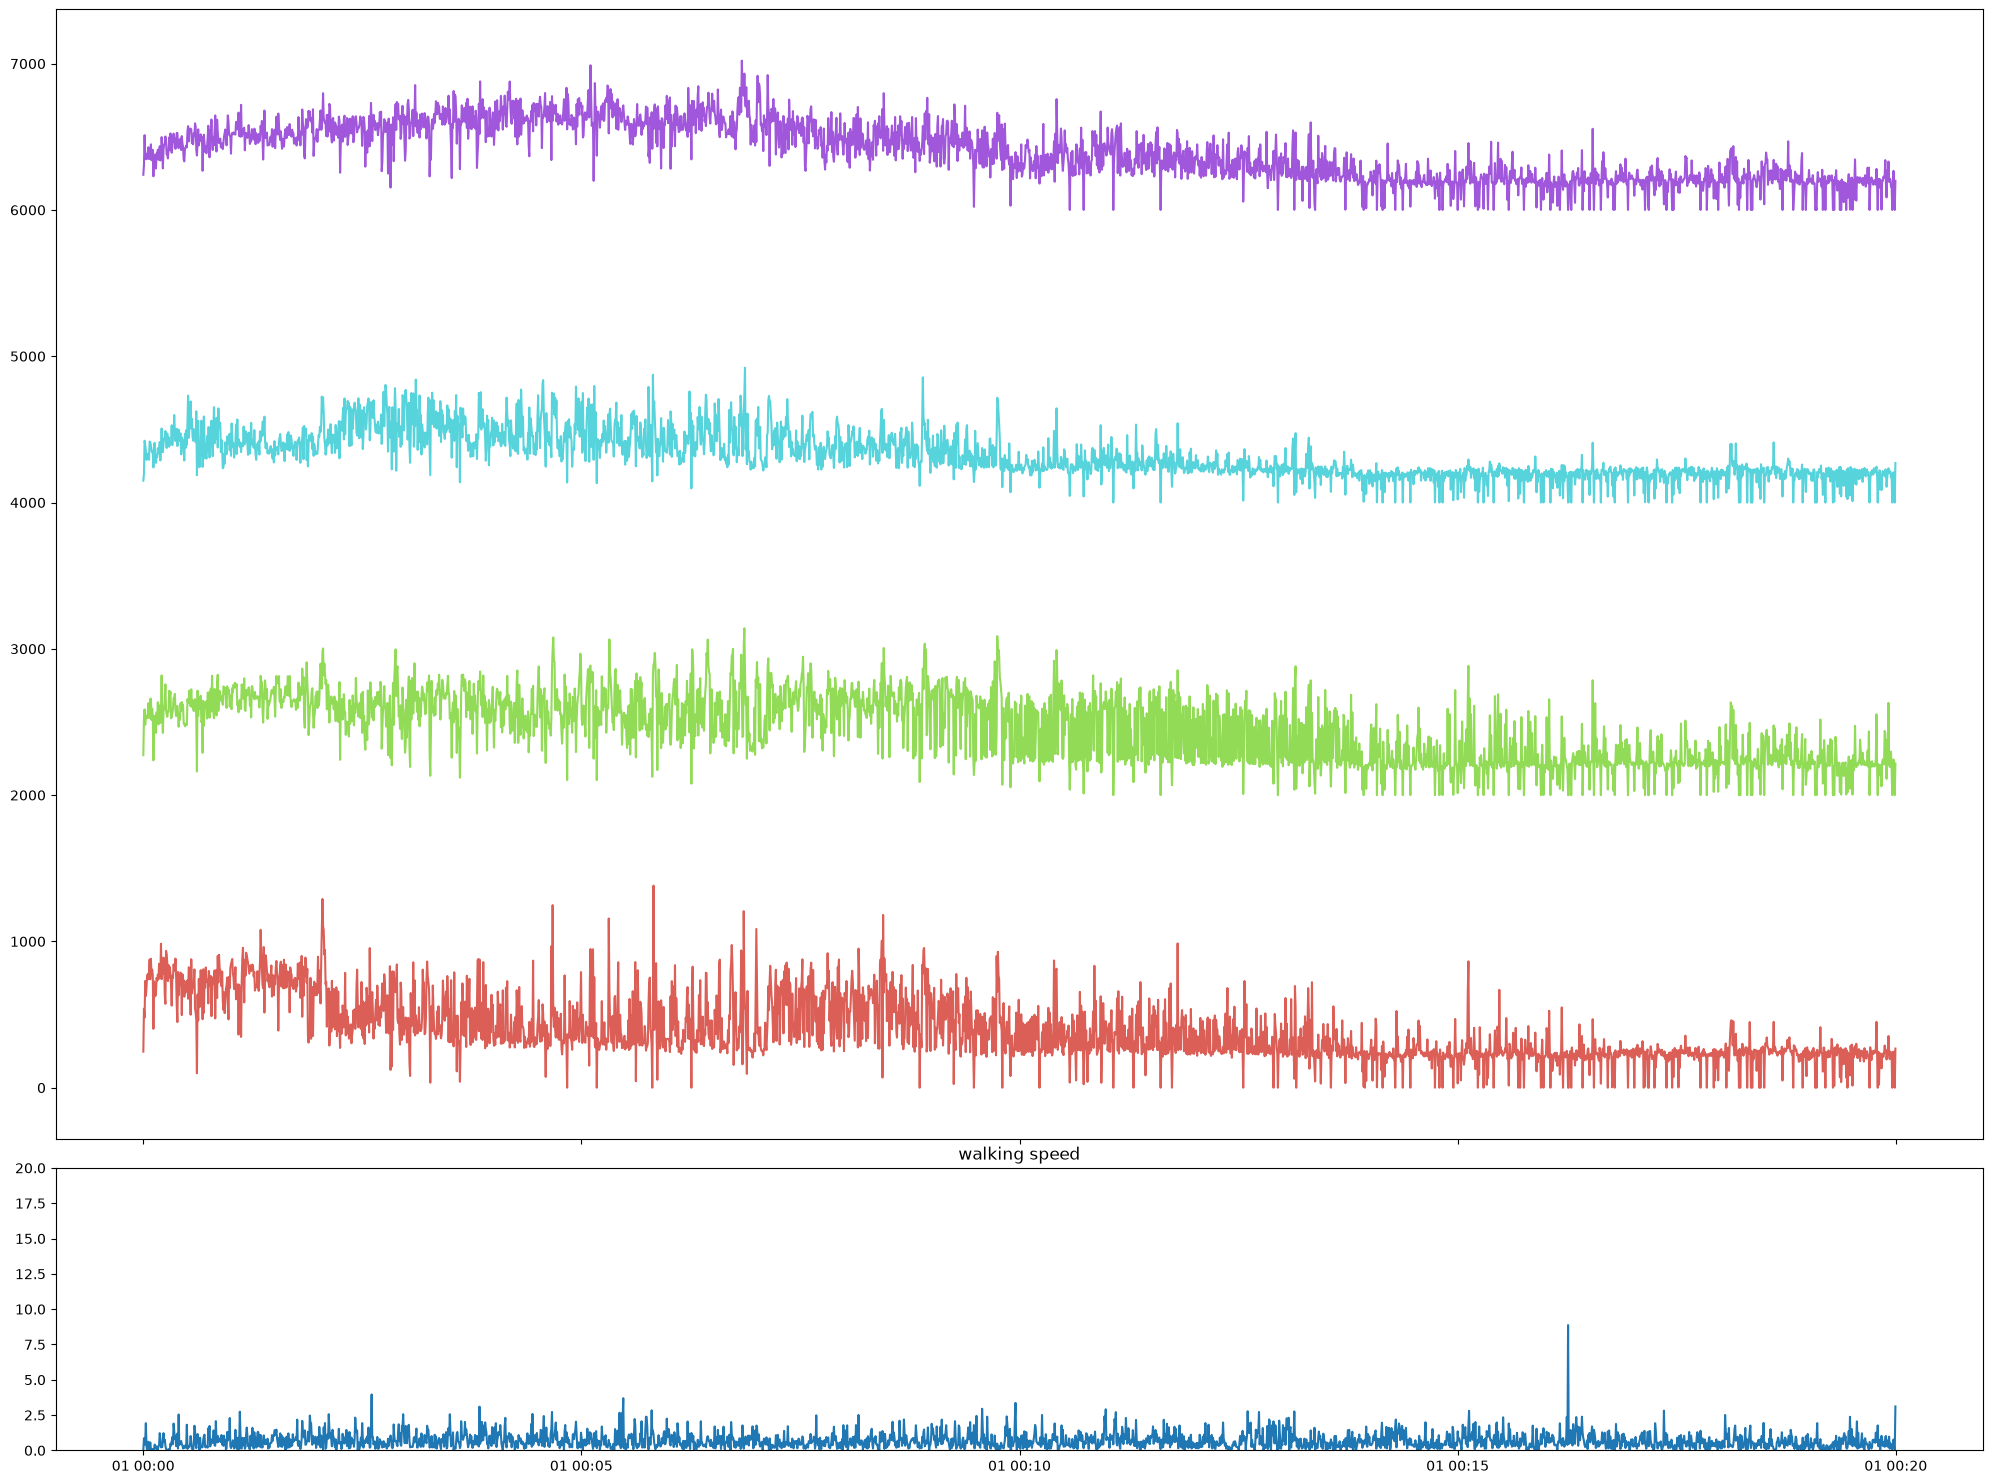

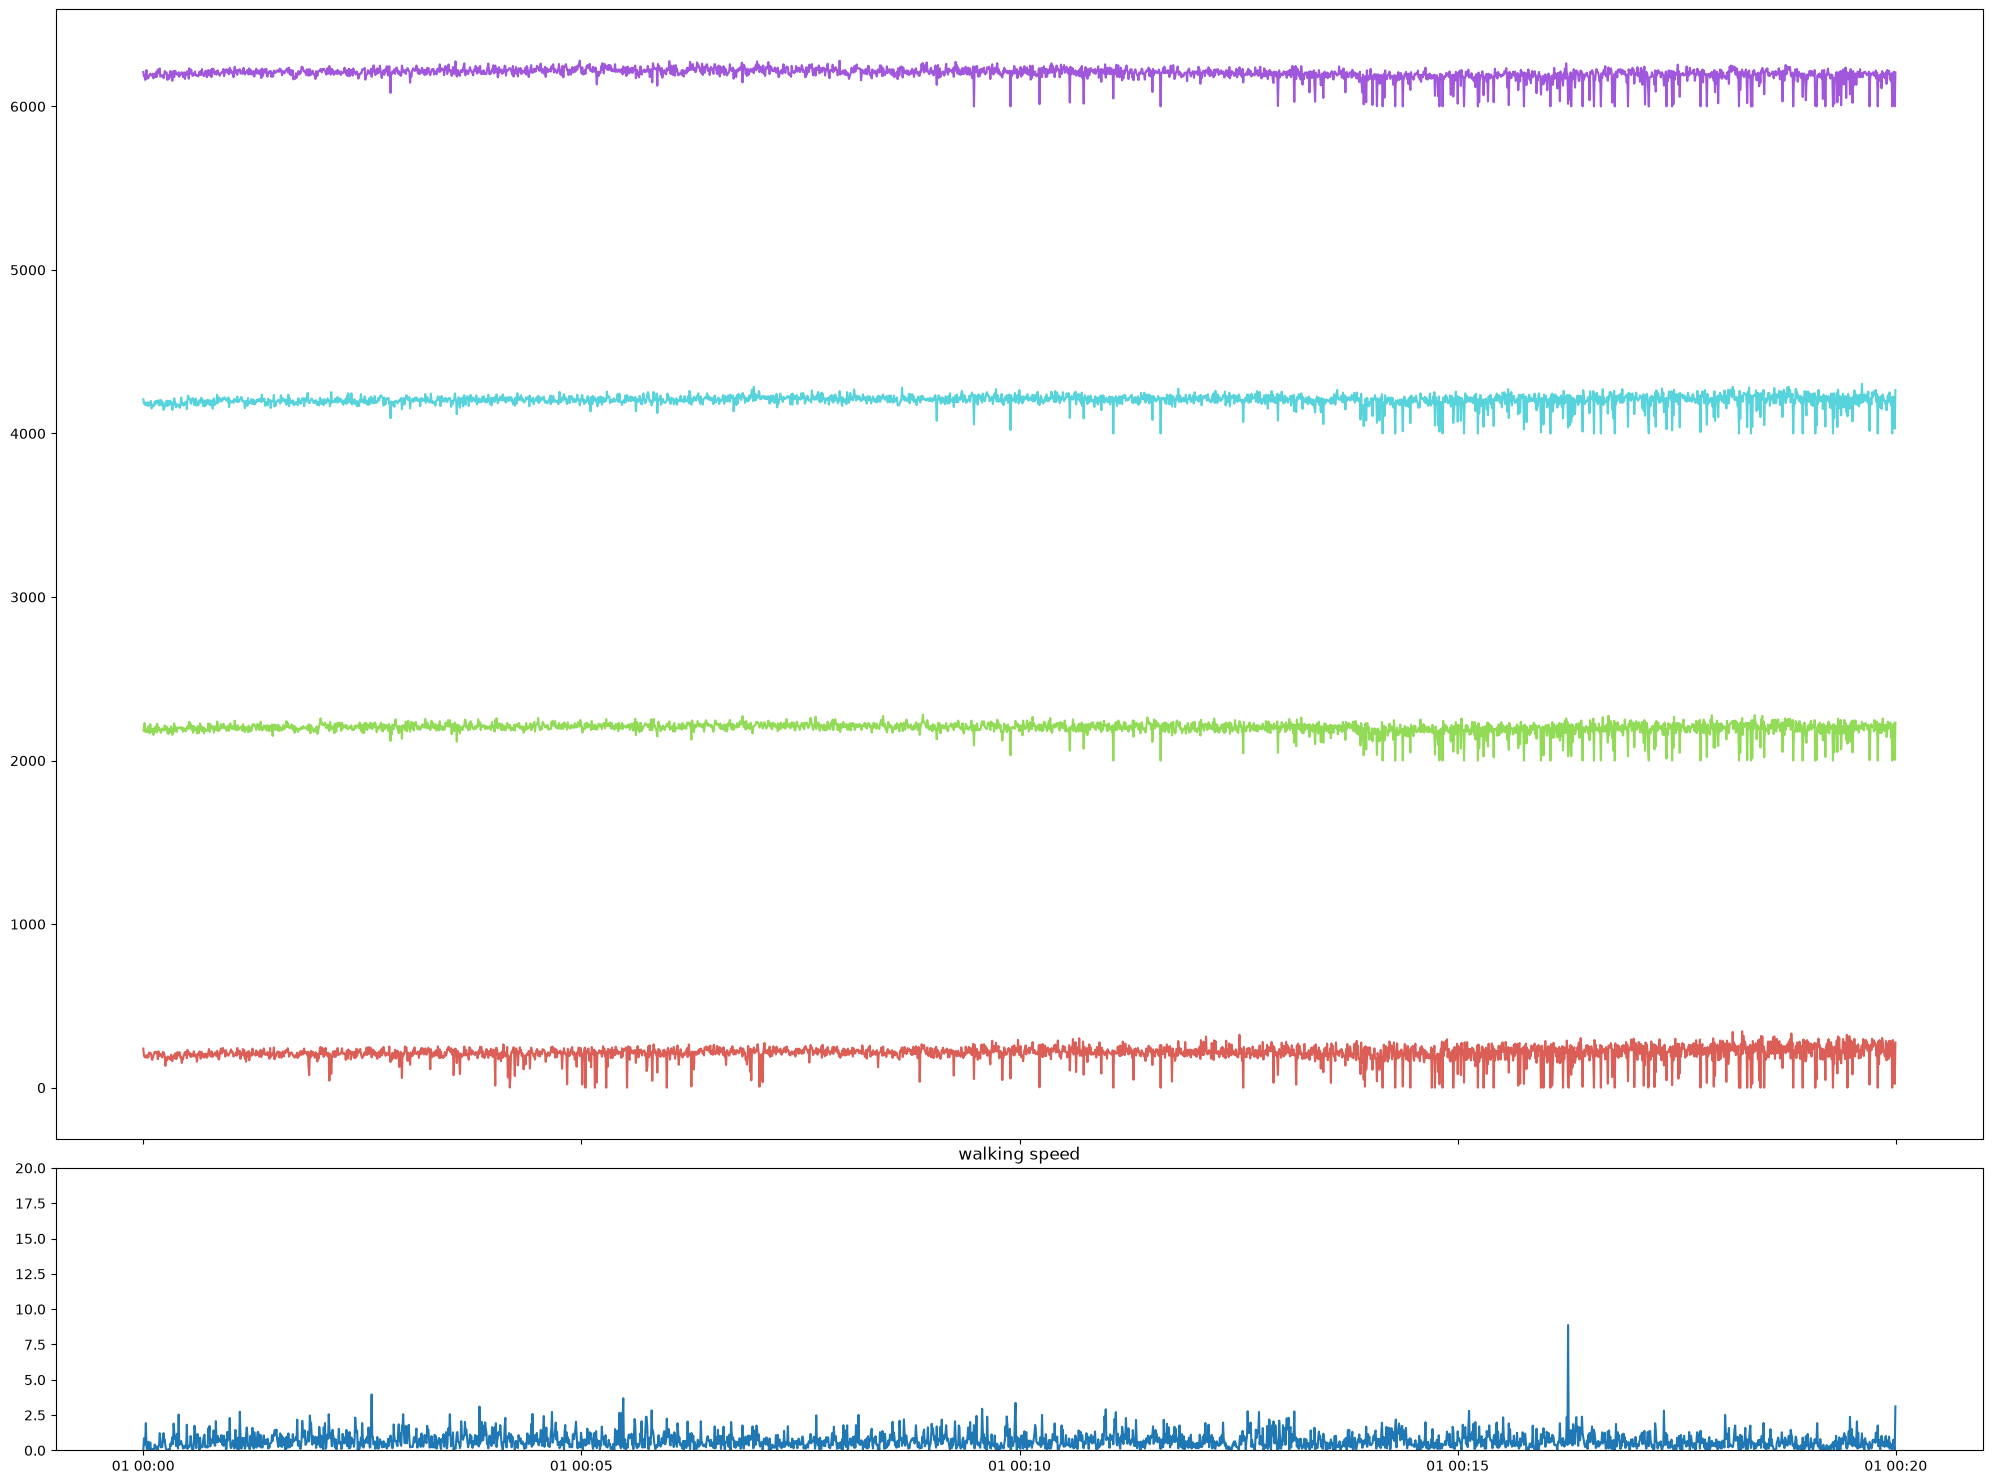

In [340]:
plot_zscored_activity(pip_rois, signal_xr, interp_speed, yshift = 2000)
plot_zscored_activity(pip_rois, sh_signal_xr, interp_speed, yshift = 2000)

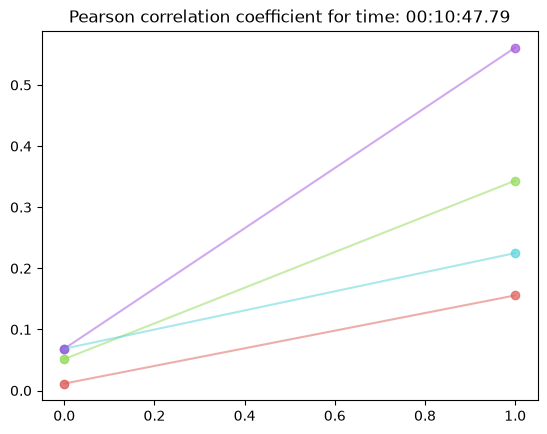

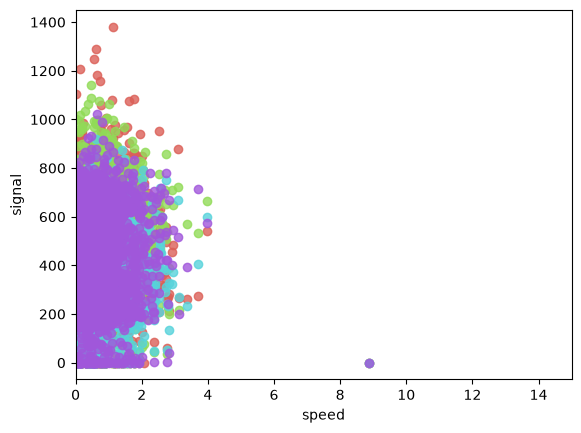

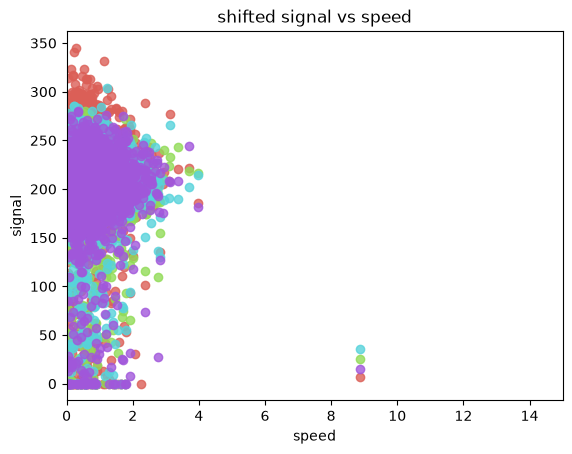

In [341]:
n_pip = len(pip_rois)
palette_colors = sns.color_palette("hls", n_pip)

fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()
fig3, ax3 = plt.subplots()
drift_time = str(signal_xr.coords['time'].values[DRIFT_INDEX])

time_title = drift_time[11:-7]


for i, pip in enumerate(pip_rois):
    to_plot = correlation.isel(zposs=pip[0], roi=pip[1])
    to_plot_sh = sh_correlation.isel(zposs=pip[0], roi=pip[1])

    # color selection
    ax1.plot([0,1], [to_plot, to_plot_sh], color=palette_colors[i], alpha=0.5, label= f'{pip}')
    ax1.scatter(0, to_plot, color=palette_colors[i], alpha=0.8)
    ax1.scatter(1, to_plot_sh, color=palette_colors[i], alpha=0.7)

    ax2.scatter(speed_shared.values, signal_shared.isel(zposs=pip[0], roi=pip[1]), color=palette_colors[i], alpha=0.8)
    ax2.set_xlabel('speed')
    ax2.set_ylabel('signal')
    ax2.set_xlim(0,15)

    ax3.scatter(speed_shared.values, sh_signal_shared.isel(zposs=pip[0], roi=pip[1]), color=palette_colors[i], alpha=0.8)
    ax3.set_xlabel('speed')
    ax3.set_ylabel('signal')
    ax3.set_xlim(0,15)
    ax3.set_title('shifted signal vs speed')

    ax1.set_title(f'Pearson correlation coefficient for time: {time_title}')

In [342]:
# how to load in clusters and timestamps